# 📊 Análise Exploratória (EDA) — camada Gold da Fase 2

Explora a base analítica de alfabetização (INEP/SAEB) consolidada pela pipeline
da Fase 2. Objetivo: entender estrutura, distribuições, correlações e
volatilidade — e registrar as hipóteses que orientam a modelagem (`03a`, `03b`).

- **Unidade:** (município, ano). **Anos:** 2023 e 2024.
- **Fonte:** `src/preprocessing/gold_consumer.load_gold` (cache local de
  `s3://tech-challenge-fase2-fiap-vitor/layers/gold`).


In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 4.5)

from src.preprocessing.gold_consumer import load_gold

gold = load_gold("indicador_municipio")
gold["id_municipio"] = gold["id_municipio"].astype("int64")  # vem como string da Gold particionada
painel = load_gold("painel_nacional")

# nomes de municípios / UF / região (cache do IBGE em data/raw/; busca se faltar)
ibge_path = Path("../data/raw/municipios_ibge.csv")
if ibge_path.exists():
    ibge = pd.read_csv(ibge_path)
else:
    import requests
    _r = requests.get("https://servicodados.ibge.gov.br/api/v1/localidades/municipios", timeout=30)
    _d = pd.DataFrame(_r.json())[["id", "nome"]].rename(columns={"id": "id_municipio", "nome": "nome_municipio"})
    _UF = {11:"RO",12:"AC",13:"AM",14:"RR",15:"PA",16:"AP",17:"TO",21:"MA",22:"PI",23:"CE",24:"RN",
           25:"PB",26:"PE",27:"AL",28:"SE",29:"BA",31:"MG",32:"ES",33:"RJ",35:"SP",41:"PR",42:"SC",
           43:"RS",50:"MS",51:"MT",52:"GO",53:"DF"}
    _REG = {1:"Norte",2:"Nordeste",3:"Sudeste",4:"Sul",5:"Centro-Oeste"}
    _d["cod_uf"] = _d.id_municipio.astype(str).str.zfill(7).str[:2].astype(int)
    _d["sigla_uf"] = _d.cod_uf.map(_UF)
    _d["regiao"] = _d.cod_uf.astype(str).str[0].astype(int).map(_REG)
    _d.to_csv(ibge_path, index=False); ibge = _d

print("Gold:", gold.shape, "| anos:", sorted(gold.ano.unique()))
gold.head()


2026-09-05 13:13:29 [INFO] Usando cache local: data\gold\indicador_municipio.parquet


2026-09-05 13:13:29 [INFO] Usando cache local: data\gold\painel_nacional.parquet


Gold: (11030, 18) | anos: [np.int64(2023), np.int64(2024)]


,id_municipio,taxa_alfabetizacao,media_portugues,taxa_meta_base,meta_2024,meta_2025,meta_2026,meta_2027,meta_2028,meta_2029,meta_2030,nivel_alfabetizacao,percentual_participacao,meta_ano_vigente,diferenca_meta,bateu_meta_2030,classificacao,ano
0,1100015,64.55,758.33,64.6,67.08,69.51,71.84,74.06,76.16,78.14,80.0,3,89.37,NaN,NaN,False,Sem meta definida,2023
1,1100023,62.30,757.10,62.3,65.22,68.02,70.71,73.25,75.65,77.90,80.0,3,89.79,NaN,NaN,False,Sem meta definida,2023
2,1100031,69.10,767.88,69.1,70.85,72.53,74.15,75.71,77.21,78.64,80.0,3,90.48,NaN,NaN,False,Sem meta definida,2023
3,1100049,64.00,758.22,62.5,65.39,68.16,70.81,73.33,75.70,77.92,80.0,3,84.44,NaN,NaN,False,Sem meta definida,2023
4,1100056,58.53,746.46,58.5,62.09,65.53,68.81,71.91,74.81,77.51,80.0,2,92.12,NaN,NaN,False,Sem meta definida,2023


## 1. Visão geral

In [2]:
gold.info()
gold.describe().T


<class 'pandas.DataFrame'>
RangeIndex: 11030 entries, 0 to 11029
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_municipio             11030 non-null  int64  
 1   taxa_alfabetizacao       11030 non-null  float64
 2   media_portugues          11030 non-null  float64
 3   taxa_meta_base           10584 non-null  float64
 4   meta_2024                10464 non-null  float64
 5   meta_2025                10671 non-null  float64
 6   meta_2026                10671 non-null  float64
 7   meta_2027                10671 non-null  float64
 8   meta_2028                10671 non-null  float64
 9   meta_2029                10671 non-null  float64
 10  meta_2030                10671 non-null  float64
 11  nivel_alfabetizacao      10584 non-null  str    
 12  percentual_participacao  10584 non-null  float64
 13  meta_ano_vigente         5232 non-null   float64
 14  diferenca_meta           5232 non

,count,mean,std,min,25%,50%,75%,max
id_municipio,11030.0,3259536.018223,978454.098521,1100015.0,2512927.25,3146750.0,4118907.0,5300108.0
taxa_alfabetizacao,11030.0,61.968573,19.280772,4.4,48.0,62.63,76.74,100.0
media_portugues,11030.0,752.100744,23.087799,673.3,736.84,751.2,764.64,868.46
taxa_meta_base,10584.0,61.774719,19.52754,4.4,47.6,62.445,76.7425,100.0
meta_2024,10464.0,62.151745,15.097461,7.94,52.17,64.095,75.885,80.0
meta_2025,10671.0,65.268532,12.617667,14.05,57.19,66.96,76.53,80.0
meta_2026,10671.0,68.57597,9.843564,23.65,62.46,69.9,77.255,80.0
meta_2027,10671.0,71.784966,7.051719,37.0,67.44,72.68,77.965,80.0
meta_2028,10671.0,74.802936,4.395251,52.68,72.06,75.3,78.66,80.0
meta_2029,10671.0,77.55584,2.015952,67.85,76.26,77.74,79.335,80.0


In [3]:
(gold.isna().mean() * 100).round(1).sort_values(ascending=False).to_frame("% nulos")


,% nulos
meta_ano_vigente,52.6
diferenca_meta,52.6
meta_2024,5.1
percentual_participacao,4.0
nivel_alfabetizacao,4.0
taxa_meta_base,4.0
meta_2030,3.3
meta_2029,3.3
meta_2025,3.3
meta_2026,3.3


**Leitura:**
- 1 linha por (município, ano) — a Gold oficial já vem sem a duplicidade
  Estadual/Privada da base bruta.
- `meta_ano_vigente` e `diferenca_meta` são ~53% nulas porque **só existem para
  2024** (em 2023 nenhum município tinha meta oficial vigente).
- As metas `meta_2024..2030` e `percentual_participacao` têm 3-5% de nulos —
  tratados por imputação **dentro da pipeline** na modelagem.


## 2. Distribuição da taxa de alfabetização

2026-09-05 13:13:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-05 13:13:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


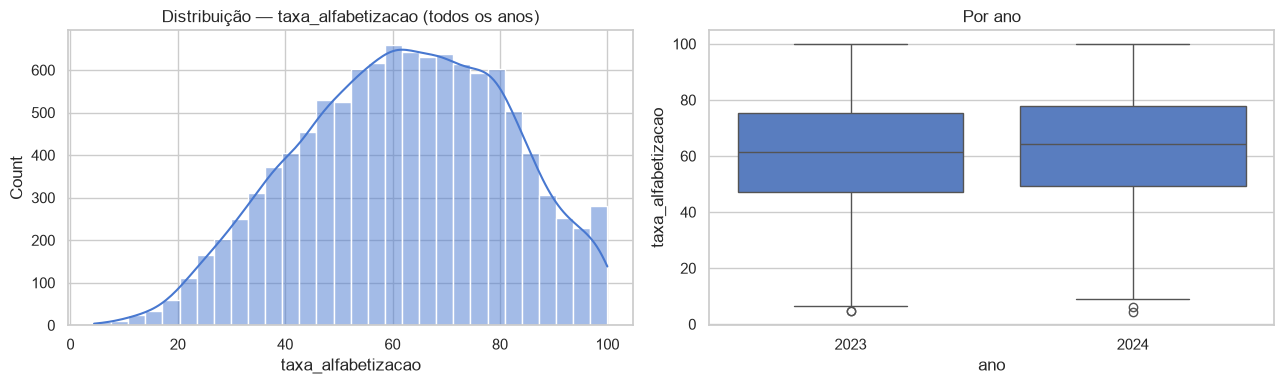

,count,mean,std,min,25%,50%,75%,max
ano,,,,,,,,
2023,5514.0,60.7,19.5,4.6,47.1,61.3,75.3,100.0
2024,5516.0,63.2,18.9,4.4,49.3,64.2,77.8,100.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(gold, x="taxa_alfabetizacao", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribuição — taxa_alfabetizacao (todos os anos)")
sns.boxplot(gold, x="ano", y="taxa_alfabetizacao", ax=axes[1])
axes[1].set_title("Por ano")
plt.tight_layout(); plt.show()
gold.groupby("ano").taxa_alfabetizacao.describe().round(1)


**Leitura:** distribuição ampla (de ~5% a ~100%), concentrada entre 50-75%,
com forte heterogeneidade entre municípios. A mediana sobe de 61,3 (2023) para
64,2 (2024).


## 3. Evolução 2023 → 2024

       mean  median  media_nacional_oficial
ano                                        
2023  60.71   61.30                   55.32
2024  63.23   64.23                   57.36


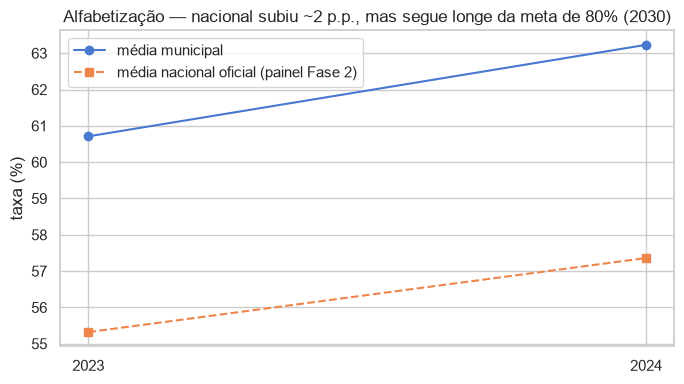

In [5]:
municipal = gold.groupby("ano").taxa_alfabetizacao.agg(["mean", "median"]).round(2)
nacional = painel.set_index("ano")["taxa_media_nacional"]
comp = municipal.join(nacional.rename("media_nacional_oficial"))
print(comp)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(comp.index, comp["mean"], "o-", label="média municipal")
ax.plot(comp.index, comp["media_nacional_oficial"], "s--", label="média nacional oficial (painel Fase 2)")
ax.set_xticks([2023, 2024]); ax.set_ylabel("taxa (%)"); ax.legend()
ax.set_title("Alfabetização — nacional subiu ~2 p.p., mas segue longe da meta de 80% (2030)")
plt.tight_layout(); plt.show()


**Leitura:** ganho nacional de ~2 p.p. em um ano. A **média nacional oficial**
(painel da Fase 2: 55,3 → 57,4) é a referência usada como corte do target de
risco na modelagem (`em_risco = taxa < média nacional do ano`).


## 4. Volatilidade ano a ano — o achado que definiu o target

Variação 2023→2024 por município:  média +2.6 p.p.  |  desvio 16.4 p.p.
  5% caíram mais de 25 p.p.  |  5% subiram mais de 30 p.p.


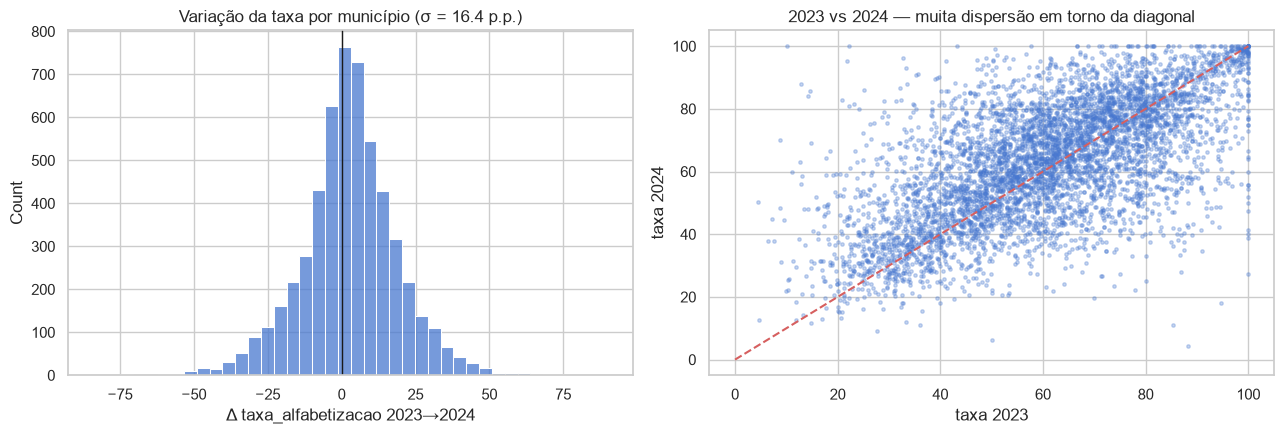

In [6]:
w = gold.pivot_table(index="id_municipio", columns="ano", values="taxa_alfabetizacao")
delta = (w[2024] - w[2023]).dropna()
print(f"Variação 2023→2024 por município:  média {delta.mean():+.1f} p.p.  |  desvio {delta.std():.1f} p.p.")
print(f"  5% caíram mais de {-delta.quantile(.05):.0f} p.p.  |  5% subiram mais de {delta.quantile(.95):.0f} p.p.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(delta, bins=40, ax=axes[0]); axes[0].axvline(0, color="k", lw=1)
axes[0].set_title(f"Variação da taxa por município (σ = {delta.std():.1f} p.p.)")
axes[0].set_xlabel("Δ taxa_alfabetizacao 2023→2024")
axes[1].scatter(w[2023], w[2024], s=6, alpha=.3)
axes[1].plot([0, 100], [0, 100], "r--"); axes[1].set_xlabel("taxa 2023"); axes[1].set_ylabel("taxa 2024")
axes[1].set_title("2023 vs 2024 — muita dispersão em torno da diagonal")
plt.tight_layout(); plt.show()


**Leitura (importante):** a taxa municipal **oscila com desvio de ~16 p.p. de
um ano para o outro** — muito acima do ganho médio nacional (~2,6 p.p.). Isso
tem duas consequências diretas na modelagem:

1. Prever se um município **cruza a própria meta anual** (fixada só ~1,4 p.p.
   acima da taxa anterior — ver seção 8) é dominado por esse ruído → quase
   imprevisível (`03b`, seção 7).
2. O alvo viável é o **nível estrutural** (estar abaixo da média nacional), que
   é bem mais estável e previsível a partir do ano anterior.

Municípios pequenos (poucos alunos avaliados) explicam boa parte dessa variância.


## 5. Correlações — e as colunas que são cópias do alvo

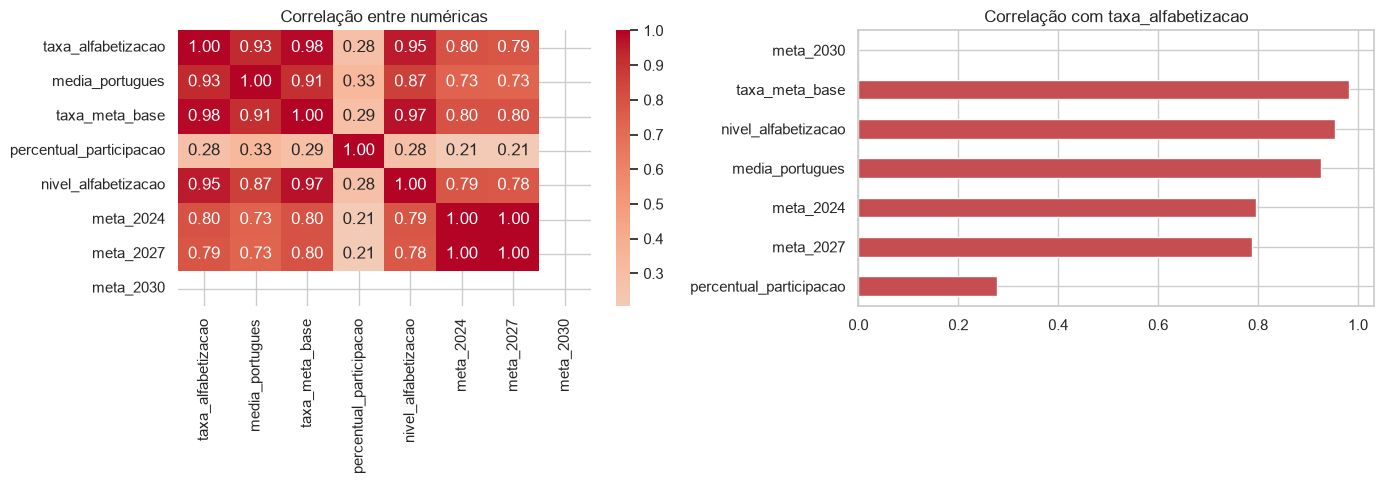

percentual_participacao    0.278
meta_2027                  0.788
meta_2024                  0.796
media_portugues            0.926
nivel_alfabetizacao        0.954
taxa_meta_base             0.983
meta_2030                    NaN
Name: taxa_alfabetizacao, dtype: float64

In [7]:
num = ["taxa_alfabetizacao", "media_portugues", "taxa_meta_base", "percentual_participacao",
       "nivel_alfabetizacao", "meta_2024", "meta_2027", "meta_2030"]
d = gold.copy()
d["nivel_alfabetizacao"] = pd.to_numeric(d["nivel_alfabetizacao"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(d[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlação entre numéricas")
corr_alvo = d[num].corr()["taxa_alfabetizacao"].drop("taxa_alfabetizacao").sort_values()
corr_alvo.plot.barh(ax=axes[1], color="#c44e52")
axes[1].set_title("Correlação com taxa_alfabetizacao")
plt.tight_layout(); plt.show()
corr_alvo.round(3)


**Leitura (data leakage):**
- `taxa_meta_base` (r ≈ 0,98) e `media_portugues` (r ≈ 0,93) são **quase cópias
  da própria `taxa_alfabetizacao`** — saem da mesma prova / mesmo ano. **Não
  podem ser features** de um modelo que se propõe a prever a taxa. Diagnóstico
  completo em `03a_diagnostico_vazamento_dados.ipynb`.
- `nivel_alfabetizacao` é uma faixa da própria taxa (idem).
- As metas (`meta_*`, r ≈ 0,79) correlacionam forte porque são **derivadas da
  taxa-base do município** — não são informação independente.
- `percentual_participacao` (r ≈ 0,28) é a única correlação fraca — feature
  legítima, e usada (defasada) no modelo final.


## 6. Recorte regional — para a pergunta de negócio sobre regiões

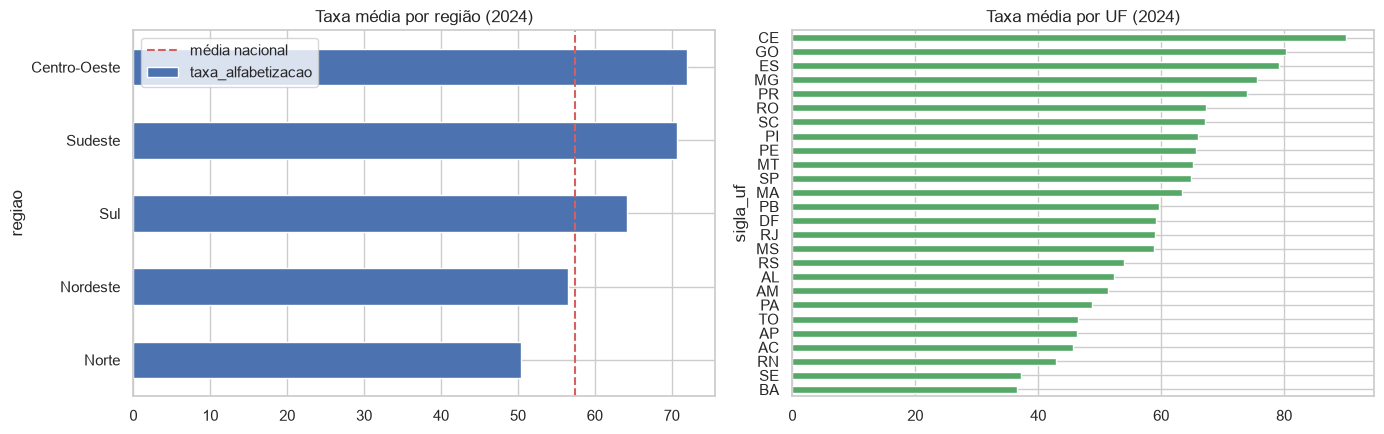

ano,2023,2024
regiao,,
Centro-Oeste,64.2,72.0
Nordeste,53.2,56.5
Norte,46.8,50.4
Sudeste,62.8,70.7
Sul,72.7,64.1


In [8]:
g = gold.merge(ibge[["id_municipio", "nome_municipio", "sigla_uf", "regiao"]], on="id_municipio", how="left")
g24 = g[g.ano == 2024]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
g24.groupby("regiao").taxa_alfabetizacao.mean().sort_values().plot.barh(ax=axes[0], color="#4c72b0")
axes[0].axvline(painel.set_index("ano").loc[2024, "taxa_media_nacional"], color="r", ls="--", label="média nacional")
axes[0].set_title("Taxa média por região (2024)"); axes[0].legend()
g24.groupby("sigla_uf").taxa_alfabetizacao.mean().sort_values().plot.barh(ax=axes[1], color="#55a868")
axes[1].set_title("Taxa média por UF (2024)")
plt.tight_layout(); plt.show()

pd.crosstab(g.regiao, g.ano, values=g.taxa_alfabetizacao, aggfunc="mean").round(1)


**Leitura:** desigualdade regional forte e persistente — **Norte (50,4) e
Nordeste (56,5)** ficam abaixo da média nacional (57,4); **Sudeste (70,7) e
Centro-Oeste (72,0)** bem acima. O risco educacional se concentra geograficamente,
o que sustenta a análise por região/UF na entrega (e a CV do modelo é feita por
UF, segurando estados inteiros fora do treino).


## 7. Ranking de municípios (2024)

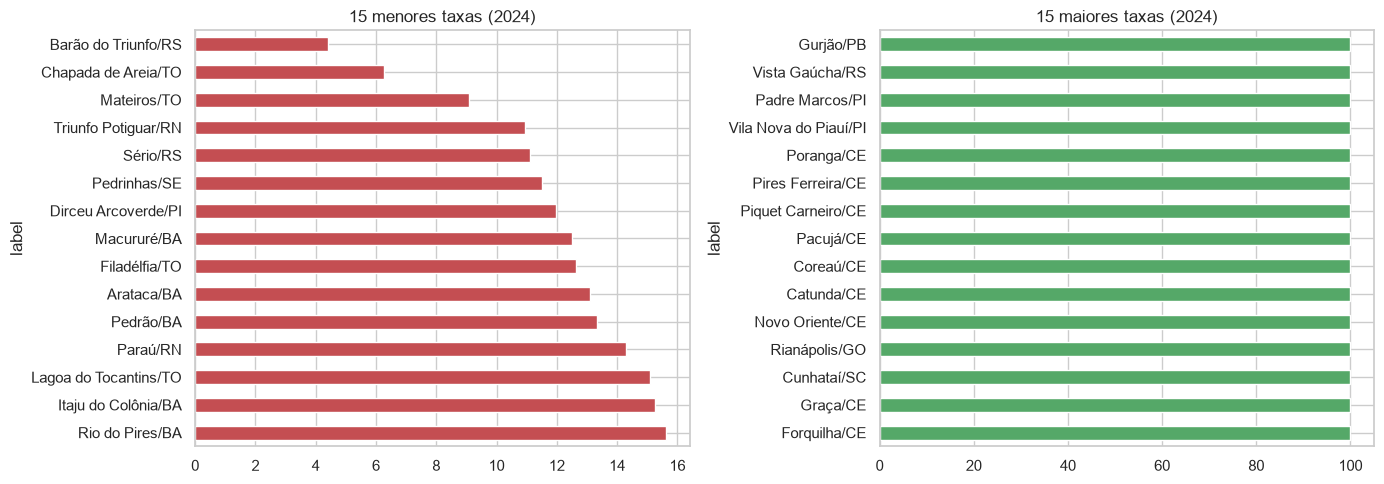

In [9]:
r = g24.dropna(subset=["nome_municipio"]).assign(
    label=lambda x: x.nome_municipio + "/" + x.sigla_uf).sort_values("taxa_alfabetizacao")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
r.head(15).plot.barh(x="label", y="taxa_alfabetizacao", ax=axes[0], color="#c44e52", legend=False)
axes[0].set_title("15 menores taxas (2024)"); axes[0].invert_yaxis()
r.tail(15).plot.barh(x="label", y="taxa_alfabetizacao", ax=axes[1], color="#55a868", legend=False)
axes[1].set_title("15 maiores taxas (2024)"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()


## 8. Meta vs. realizado (2024)

54.0% dos municípios atingiram a meta vigente em 2024
{'Acima da meta': 2063, 'Muito abaixo da meta': 1647, 'Na meta': 761, 'Abaixo da meta': 761}

meta_2024 - taxa_2023 (quanto o município precisava subir): média +1.4 p.p., mediana +2.9
-> a meta é fixada logo acima da taxa anterior; combinada com a volatilidade de ~16 p.p.,
   atingir a meta em um ano específico é quase sorte. Ver 03b, seção 7.


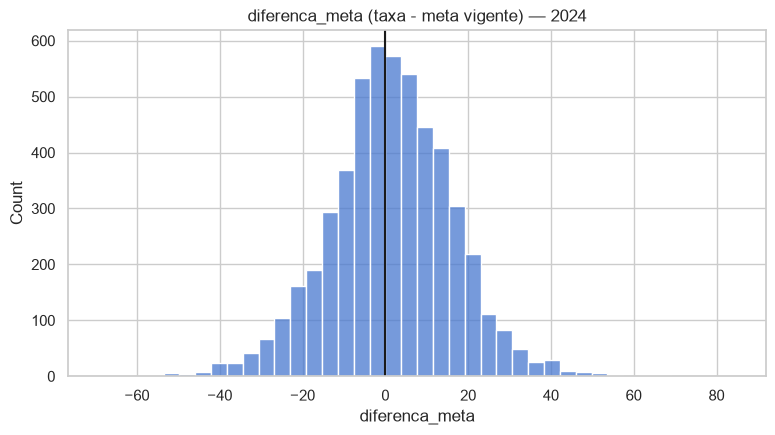

In [10]:
s = g24.dropna(subset=["meta_ano_vigente"]).copy()
print(f"{(s.taxa_alfabetizacao >= s.meta_ano_vigente).mean():.1%} dos municípios atingiram a meta vigente em 2024")
print(s.classificacao.value_counts().to_dict())

folga = (s.set_index("id_municipio").meta_ano_vigente - w[2023]).dropna()
print(f"\nmeta_2024 - taxa_2023 (quanto o município precisava subir): média {folga.mean():+.1f} p.p., mediana {folga.median():+.1f}")
print("-> a meta é fixada logo acima da taxa anterior; combinada com a volatilidade de ~16 p.p.,")
print("   atingir a meta em um ano específico é quase sorte. Ver 03b, seção 7.")

sns.histplot(s.diferenca_meta.dropna(), bins=40); plt.axvline(0, color="k")
plt.title("diferenca_meta (taxa - meta vigente) — 2024"); plt.show()


## 9. Hipóteses analíticas (revisadas) e impacto na modelagem

| # | Hipótese | Status | Impacto |
|---|---|---|---|
| **H1** | `percentual_participacao` isolada tem pouco poder preditivo | ✅ **Confirmada** (r ≈ 0,28) | Entra no modelo, mas como coadjuvante |
| **H2** | As metas do programa carregam sinal estrutural | ⚠️ **Parcial** — correlacionam (r ≈ 0,79), mas por serem derivadas da taxa-base do próprio município; não são informação independente | Não usadas como feature; `meta` só como referência/threshold |
| **H3** | `diferenca_meta`, `bateu_meta_2030`, `nivel_alfabetizacao`, `classificacao` são rótulos derivados do alvo | ✅ **Confirmada** | Excluídas das features (leakage direto) |
| **H4** | A heterogeneidade entre municípios domina a evolução temporal | ✅ **Confirmada e reforçada** — Δ nacional +2,6 p.p. vs σ do Δ municipal ≈ 16 p.p. | Teto de performance moderado; validação por UF; target = nível estrutural |
| **H5** *(nova)* | A meta anual é apertada demais frente à volatilidade → prever atingimento de meta é ~ruído | ✅ **Confirmada** (`03b` seção 7: ROC-AUC ≈ 0,60) | Target reformulado para "abaixo da média nacional" (ROC-AUC ≈ 0,82); atingimento de meta reportado como **achado**, não como modelo |
| **H6** *(nova)* | O risco educacional tem padrão regional forte | ✅ **Confirmada** — Norte/Nordeste abaixo da média; Sudeste/CO acima | Análise por região/UF na entrega; CV `GroupKFold` por UF |
